<a href="https://colab.research.google.com/github/usuyama/pytorch-unet/blob/master/pytorch_unet_resnet18_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## 載入套件


In [ ]:
import os, time
from collections import defaultdict
from typing import Any, Callable, Dict, List, Optional, cast

import helper
import matplotlib.pyplot as plt
import numpy as np
import simulation  # simulation.py
import torch
from torch import nn, optim
from torch.nn import functional as F
from loss import dice_loss
from torch.optim import Optimizer, lr_scheduler
from torch.utils.data import DataLoader, Dataset
from torchsummary import summary
from torchvision import models, transforms

## pytorch-uent

https://github.com/usuyama/pytorch-unet


In [2]:
if not os.path.exists("pytorch_unet"):
    !git clone https://github.com/usuyama/pytorch-unet.git

%cd pytorch-unet

致命錯誤: 目的地路徑 'pytorch-unet' 已經存在，並且不是一個空目錄。
/Users/rikenmi/Work/study/python/PyTorch_Book/src/pytorch-unet


In [3]:
!ls

LICENSE                           pytorch_fcn.ipynb
README.md                         pytorch_resnet18_unet.ipynb
checkpoint.pth                    pytorch_unet.ipynb
helper.py                         pytorch_unet.py
images                            pytorch_unet_resnet18_colab.ipynb
loss.py                           simulation.py


## Enabling GPU on Colab

Need to enable GPU from Notebook settings

- Navigate to Edit-Notebook settings menu
- Select GPU from the Hardware Accelerator dropdown list


In [4]:
if not torch.cuda.is_available() and not torch.mps.is_available():
    raise Exception("GPU not availalbe. CPU training will be too slow.")

if torch.cuda.is_available():
    print("device name", torch.cuda.get_device_name(0))
elif torch.mps.is_available():
    print("device name", 'mps')

device name mps


## 測試 simulation.py 生成的圖像


input_images shape and range (3, 192, 192, 3) 0 255
target_masks shape and range (3, 6, 192, 192) 0.0 1.0


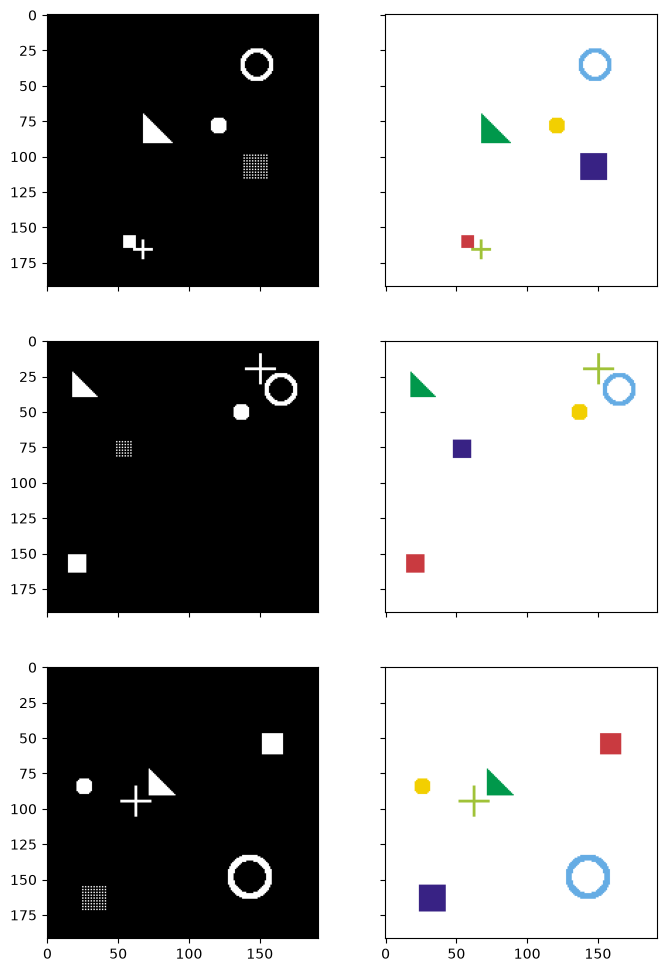

In [5]:
# 產生3張圖像，寬高各為 192，裡面有6個隨機擺放的圖案。
input_images, target_masks = simulation.generate_random_data(192, 192, count=3)

print("input_images shape and range", input_images.shape, input_images.min(), input_images.max())
print("target_masks shape and range", target_masks.shape, target_masks.min(), target_masks.max())

# 輸入圖像，改為單色
input_images_rgb = [x.astype(np.uint8) for x in input_images]

# 遮罩(Mask)圖像，使用彩色
target_masks_rgb = [helper.masks_to_colorimg(x) for x in target_masks]

# 顯示圖像：左邊原圖為輸入，右邊遮罩(Mask)圖像為目標
helper.plot_side_by_side([input_images_rgb, target_masks_rgb])

## 建立 Dataset


In [6]:
# 自訂資料集，一次傳回原圖、遮罩圖像各一個
class SimDataset(Dataset):
    def __init__(self, count: int, transform: Optional[Callable] = None) -> None:
        self.input_images, self.target_masks = simulation.generate_random_data(192, 192, count=count)
        self.transform = transform

    def __len__(self):
        return len(self.input_images)

    def __getitem__(self, idx: int) -> List[np.ndarray]:
        image = self.input_images[idx]
        mask = self.target_masks[idx]
        if self.transform:
            image = self.transform(image)

        return [image, mask]

## 建立 DataLoader


In [7]:
# 轉換
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),  # imagenet
    ]
)

# 產生訓練及驗證圖像各2000筆
train_set = SimDataset(2_000, transform=transform)
val_set = SimDataset(200, transform=transform)

image_datasets = {'train': train_set, 'val': val_set}

batch_size = 25

dataloaders = {
    'train': DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0),
    'val': DataLoader(val_set, batch_size=batch_size, shuffle=True, num_workers=0),
}

## 建立還原轉換函數，並測試一批資料


torch.Size([25, 3, 192, 192]) torch.Size([25, 6, 192, 192])


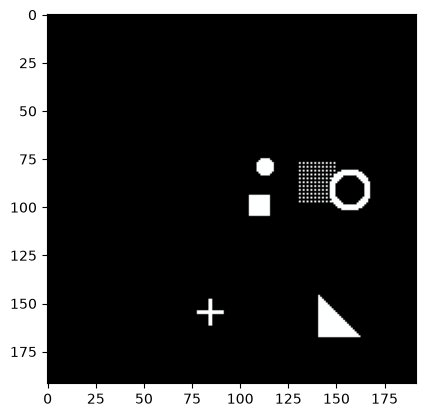

In [8]:
# 還原轉換
def reverse_transform(inp: torch.Tensor) -> np.ndarray:
    arr = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    arr = std * arr + mean
    arr = np.clip(arr, 0, 1)
    arr = (arr * 255).astype(np.uint8)

    return arr


# 取得一批資料測試
inputs, masks = next(iter(dataloaders['train']))
print(inputs.shape, masks.shape)
plt.imshow(reverse_transform(inputs[3]))

# 建立 U-Net 模型


In [9]:
def convrelu(in_channels: int, out_channels: int, kernel: int, padding: int) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel, padding=padding),
        nn.ReLU(inplace=True),
    )


class ResNetUNet(nn.Module):
    def __init__(self, n_class):
        super(ResNetUNet, self).__init__()

        # 載入 resnet18 模型
        self.base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.base_layers = list(self.base_model.children())

        self.layer0 = nn.Sequential(*self.base_layers[:3])  # size=(N, 64, x.H/2, x.W/2)
        self.layer0_1x1 = convrelu(64, 64, 1, 0)
        self.layer1 = nn.Sequential(*self.base_layers[3:5])  # size=(N, 64, x.H/4, x.W/4)
        self.layer1_1x1 = convrelu(64, 64, 1, 0)
        self.layer2 = self.base_layers[5]  # size=(N, 128, x.H/8, x.W/8)
        self.layer2_1x1 = convrelu(128, 128, 1, 0)
        self.layer3 = self.base_layers[6]  # size=(N, 256, x.H/16, x.W/16)
        self.layer3_1x1 = convrelu(256, 256, 1, 0)
        self.layer4 = self.base_layers[7]  # size=(N, 512, x.H/32, x.W/32)
        self.layer4_1x1 = convrelu(512, 512, 1, 0)

        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.conv_up3 = convrelu(256 + 512, 512, 3, 1)
        self.conv_up2 = convrelu(128 + 512, 256, 3, 1)
        self.conv_up1 = convrelu(64 + 256, 256, 3, 1)
        self.conv_up0 = convrelu(64 + 256, 128, 3, 1)

        self.conv_original_size0 = convrelu(3, 64, 3, 1)
        self.conv_original_size1 = convrelu(64, 64, 3, 1)
        self.conv_original_size2 = convrelu(64 + 128, 64, 3, 1)

        self.conv_last = nn.Conv2d(64, n_class, 1)

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        x_original = self.conv_original_size0(input)
        x_original = self.conv_original_size1(x_original)

        layer0 = self.layer0(input)
        layer1 = self.layer1(layer0)
        layer2 = self.layer2(layer1)
        layer3 = self.layer3(layer2)
        layer4 = self.layer4(layer3)

        layer4 = self.layer4_1x1(layer4)
        x = self.upsample(layer4)
        layer3 = self.layer3_1x1(layer3)
        x = torch.cat([x, layer3], dim=1)
        x = self.conv_up3(x)

        # 新增神經層
        x = self.upsample(x)
        # 對面的神經層
        layer2 = self.layer2_1x1(layer2)
        # 連接新增的神經層及對面的神經層
        x = torch.cat([x, layer2], dim=1)
        x = self.conv_up2(x)

        x = self.upsample(x)
        layer1 = self.layer1_1x1(layer1)
        x = torch.cat([x, layer1], dim=1)
        x = self.conv_up1(x)

        x = self.upsample(x)
        layer0 = self.layer0_1x1(layer0)
        x = torch.cat([x, layer0], dim=1)
        x = self.conv_up0(x)

        x = self.upsample(x)
        x = torch.cat([x, x_original], dim=1)
        x = self.conv_original_size2(x)

        out = self.conv_last(x)

        return out

## Instantiate the UNet model

- Move the model to GPU if available
- Show model summaries


In [10]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu'
print('device', device)

model = ResNetUNet(6)
model = model.to(device)

device mps


In [11]:
model

ResNetUNet(
  (base_model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-0

In [12]:
summary(model.to('cpu'), input_size=(3, 224, 224), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
            Conv2d-5         [-1, 64, 112, 112]           9,408
            Conv2d-6         [-1, 64, 112, 112]           9,408
       BatchNorm2d-7         [-1, 64, 112, 112]             128
       BatchNorm2d-8         [-1, 64, 112, 112]             128
              ReLU-9         [-1, 64, 112, 112]               0
             ReLU-10         [-1, 64, 112, 112]               0
        MaxPool2d-11           [-1, 64, 56, 56]               0
        MaxPool2d-12           [-1, 64, 56, 56]               0
           Conv2d-13           [-1, 64, 56, 56]          36,864
           Conv2d-14           [-1, 64,

## 定義損失函數


In [13]:
checkpoint_path = "checkpoint.pth"
model.to(device)

# 損失採 binary cross entropy + dice loss
def calc_loss(
    pred: torch.Tensor, target: torch.Tensor, metrics: Dict[str, float], bce_weight: float = 0.5
) -> torch.Tensor:
    bce = F.binary_cross_entropy_with_logits(pred, target)

    pred = torch.sigmoid(pred)
    dice = dice_loss(pred, target)

    loss = bce * bce_weight + dice * (1 - bce_weight)

    metrics['bce'] += bce.data.item() * target.size(0)
    metrics['dice'] += dice.data.item() * target.size(0)
    metrics['loss'] += loss.data.item() * target.size(0)

    return loss


# 計算效能衡量指標
def print_metrics(metrics: Dict[str, float], epoch_samples: int, phase: str) -> None:
    outputs = []
    for k in metrics.keys():
        outputs.append(f"{k}: {(metrics[k] / epoch_samples):4f}")

    print(f"{phase}: {', '.join(outputs)}")

## 建立訓練及評估函數


In [ ]:
def train_model(model: nn.Module, optimizer: Optimizer, scheduler: Any, num_epochs: int = 25) -> nn.Module:
    best_loss = 1e10

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        since = time.time()

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluate mode

            metrics = defaultdict(float)
            epoch_samples = 0

            inputs: torch.Tensor
            labels: torch.Tensor
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = calc_loss(outputs, labels, metrics)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                epoch_samples += inputs.size(0)

            print_metrics(metrics, epoch_samples, phase)
            epoch_loss = metrics['loss'] / epoch_samples

            if phase == 'train':
                scheduler.step()
                for param_group in optimizer.param_groups:
                    print("LR", param_group['lr'])

            # save the model weights
            if phase == 'val' and epoch_loss < best_loss:
                print(f"saving best model to {checkpoint_path}")
                best_loss = epoch_loss
                torch.save(model.state_dict(), checkpoint_path)

        time_elapsed = time.time() - since
        print(f'{(time_elapsed // 60):.0f}m {(time_elapsed % 60):.0f}s')

    print(f'Best val loss: {best_loss:4f}')

    # load best model weights
    model.load_state_dict(torch.load(checkpoint_path))
    return model

## 訓練


In [15]:
num_class = 6
model = ResNetUNet(num_class).to(device)

# freeze backbone layers
for l in model.base_layers:
    for param in l.parameters():
        param.requires_grad = False

optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=8, gamma=0.1)

model = train_model(model, optimizer_ft, exp_lr_scheduler, num_epochs=10)

Epoch 0/9
----------
train: bce: 0.100964, dice: 0.964279, loss: 0.532621
LR 0.0001
val: bce: 0.018834, dice: 0.778162, loss: 0.398498
saving best model to checkpoint.pth
0m 32s
Epoch 1/9
----------
train: bce: 0.012550, dice: 0.534164, loss: 0.273357
LR 0.0001
val: bce: 0.005839, dice: 0.283254, loss: 0.144547
saving best model to checkpoint.pth
0m 33s
Epoch 2/9
----------
train: bce: 0.003026, dice: 0.148860, loss: 0.075943
LR 0.0001
val: bce: 0.002286, dice: 0.087114, loss: 0.044700
saving best model to checkpoint.pth
0m 32s
Epoch 3/9
----------
train: bce: 0.001695, dice: 0.064180, loss: 0.032938
LR 0.0001
val: bce: 0.002132, dice: 0.063051, loss: 0.032591
saving best model to checkpoint.pth
0m 33s
Epoch 4/9
----------
train: bce: 0.001479, dice: 0.049638, loss: 0.025558
LR 0.0001
val: bce: 0.001986, dice: 0.056388, loss: 0.029187
saving best model to checkpoint.pth
0m 33s
Epoch 5/9
----------
train: bce: 0.001358, dice: 0.043402, loss: 0.022380
LR 0.0001
val: bce: 0.001933, dice: 

## 預測


inputs.shape torch.Size([3, 3, 192, 192])
labels.shape torch.Size([3, 6, 192, 192])
pred.shape (3, 6, 192, 192)


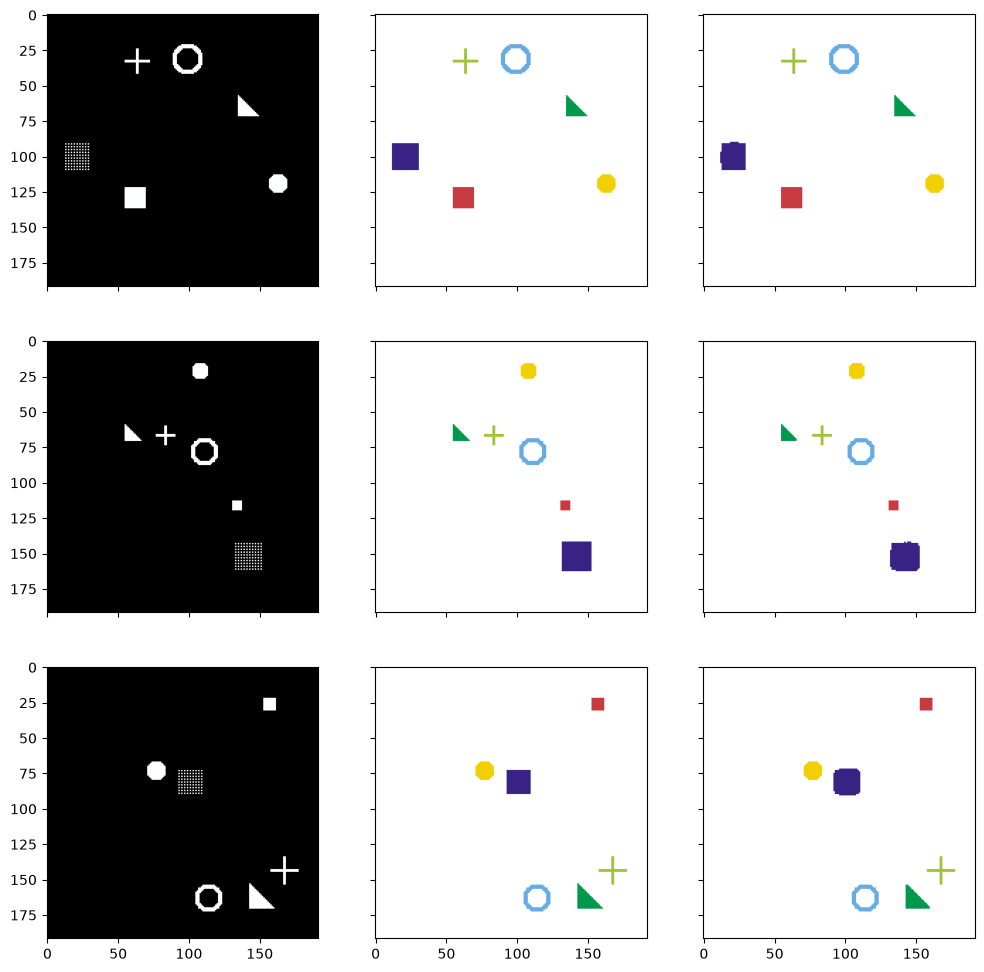

In [16]:
# 建立新資料
test_dataset = SimDataset(3, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=3, shuffle=False, num_workers=0)

# 取一批資料測試
inputs, labels = cast(tuple[torch.Tensor, torch.Tensor], next(iter(test_loader)))
inputs = inputs.to(device)
labels = labels.to(device)
print('inputs.shape', inputs.shape)
print('labels.shape', labels.shape)

# 預測
model.eval()
pred = model(inputs)
pred = torch.sigmoid(pred)  # 轉為 [0, 1] 之間
pred = pred.data.cpu().numpy()
print('pred.shape', pred.shape)

# 原圖還原轉換
input_images_rgb = [reverse_transform(x) for x in inputs.cpu()]

# 遮罩
target_masks_rgb = [helper.masks_to_colorimg(x) for x in labels.cpu().numpy()]

# 預測轉成圖像
pred_rgb = [helper.masks_to_colorimg(x) for x in pred]

## 左邊: 原圖, 中間: 遮罩圖像(target), 右邊: 預測圖像
helper.plot_side_by_side([input_images_rgb, target_masks_rgb, pred_rgb])

## Next steps

Try tweaking the hyper-parameters for better accuracy e.g.

- learning rates and schedules
- loss weights
- unfreezing layers
- batch size
- etc.
